In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import xgboost as xgb
import joblib

# Set display options
pd.set_option('display.max_columns', None)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported!")
print("💓 Agent 3: Vitals Analyst (XGBoost)")
print("=" * 60)

✅ Libraries imported!
💓 Agent 3: Vitals Analyst (XGBoost)


In [4]:
print("📊 Re-creating vital features from filtered data...")
print("=" * 60)

import os

# Check if CSV exists
csv_path = '../../data/processed/vital_features_train.csv'
if os.path.exists(csv_path):
    print(f"✅ File exists! Loading...")
    vital_features = pd.read_csv(csv_path)
else:
    print(f"⚠️  CSV not found. Re-creating from parquet...")
    
    # Load filtered vitals
    vitals_train = pd.read_parquet('../../data/processed/vitals_train_filtered.parquet')
    
    # Load training patient IDs
    train_patients = pd.read_csv('../../data/processed/train_patients.csv')
    train_patient_ids = train_patients['SUBJECT_ID'].values
    
    important_vital_codes = [220045, 220050, 220051, 220052, 220179, 220180, 
                            220181, 220210, 220277, 223761, 223762, 220339, 223835]
    
    print(f"Aggregating vitals for {len(train_patient_ids):,} patients...")
    
    agg_features = []
    
    for patient_id in tqdm(train_patient_ids, desc="Processing patients"):
        patient_vitals = vitals_train[vitals_train['SUBJECT_ID'] == patient_id]
        
        if len(patient_vitals) == 0:
            # Patient has no vitals
            features = {'SUBJECT_ID': patient_id}
            for itemid in important_vital_codes:
                features[f'vital_{itemid}_mean'] = np.nan
                features[f'vital_{itemid}_min'] = np.nan
                features[f'vital_{itemid}_max'] = np.nan
                features[f'vital_{itemid}_std'] = np.nan
                features[f'vital_{itemid}_count'] = 0
            agg_features.append(features)
            continue
        
        features = {'SUBJECT_ID': patient_id}
        
        for itemid in important_vital_codes:
            vital_values = patient_vitals[patient_vitals['ITEMID'] == itemid]['VALUENUM'].dropna()
            
            if len(vital_values) > 0:
                features[f'vital_{itemid}_mean'] = vital_values.mean()
                features[f'vital_{itemid}_min'] = vital_values.min()
                features[f'vital_{itemid}_max'] = vital_values.max()
                features[f'vital_{itemid}_std'] = vital_values.std() if len(vital_values) > 1 else 0
                features[f'vital_{itemid}_count'] = len(vital_values)
            else:
                features[f'vital_{itemid}_mean'] = np.nan
                features[f'vital_{itemid}_min'] = np.nan
                features[f'vital_{itemid}_max'] = np.nan
                features[f'vital_{itemid}_std'] = np.nan
                features[f'vital_{itemid}_count'] = 0
        
        agg_features.append(features)
    
    vital_features = pd.DataFrame(agg_features)
    
    # Save it
    vital_features.to_csv(csv_path, index=False)
    print(f"\n✅ Saved to: {csv_path}")

print(f"\n✅ Vital features ready!")
print(f"   Shape: {vital_features.shape}")
print(f"   Patients: {len(vital_features):,}")
print(f"   Features: {vital_features.shape[1] - 1} (excluding SUBJECT_ID)")

📊 Re-creating vital features from filtered data...
⚠️  CSV not found. Re-creating from parquet...
Aggregating vitals for 21,816 patients...


Processing patients: 100%|███████████████████████████████████████████████████████| 21816/21816 [05:21<00:00, 67.77it/s]



✅ Saved to: ../data/processed/vital_features_train.csv

✅ Vital features ready!
   Shape: (21816, 66)
   Patients: 21,816
   Features: 65 (excluding SUBJECT_ID)


In [5]:
print("🎯 Loading patient labels...")
print("=" * 60)

# Load multi-label targets
labels = pd.read_csv('../../data/processed/patient_multilabels.csv')

print(f"✅ Labels loaded!")
print(f"   Shape: {labels.shape}")
print(f"   Patients: {len(labels):,}")

# Disease columns
disease_cols = [
    'SEPSIS', 'PNEUMONIA', 'RESPIRATORY_FAILURE', 
    'ACUTE_KIDNEY_INJURY', 'HEART_FAILURE', 
    'ATRIAL_FIBRILLATION', 'CORONARY_ARTERY_DISEASE', 
    'ANEMIA', 'PANCREATITIS'
]

print(f"\nTarget diseases:")
print(disease_cols)

print(f"\nLabel distribution:")
for disease in disease_cols:
    count = labels[disease].sum()
    pct = count / len(labels) * 100
    print(f"  {disease:30s}: {count:6,} patients ({pct:5.1f}%)")

🎯 Loading patient labels...
✅ Labels loaded!
   Shape: (31166, 11)
   Patients: 31,166

Target diseases:
['SEPSIS', 'PNEUMONIA', 'RESPIRATORY_FAILURE', 'ACUTE_KIDNEY_INJURY', 'HEART_FAILURE', 'ATRIAL_FIBRILLATION', 'CORONARY_ARTERY_DISEASE', 'ANEMIA', 'PANCREATITIS']

Label distribution:
  SEPSIS                        :  5,865 patients ( 18.8%)
  PNEUMONIA                     :  6,531 patients ( 21.0%)
  RESPIRATORY_FAILURE           : 11,363 patients ( 36.5%)
  ACUTE_KIDNEY_INJURY           : 11,514 patients ( 36.9%)
  HEART_FAILURE                 : 10,154 patients ( 32.6%)
  ATRIAL_FIBRILLATION           : 10,552 patients ( 33.9%)
  CORONARY_ARTERY_DISEASE       : 11,926 patients ( 38.3%)
  ANEMIA                        : 10,631 patients ( 34.1%)
  PANCREATITIS                  :  4,538 patients ( 14.6%)


In [6]:
print("🔗 Merging features with labels...")
print("=" * 60)

# Merge on SUBJECT_ID
train_data = vital_features.merge(labels, on='SUBJECT_ID', how='inner')

print(f"✅ Merged successfully!")
print(f"   Combined shape: {train_data.shape}")
print(f"   Patients in both datasets: {len(train_data):,}")
print(f"   Patients lost in merge: {len(vital_features) - len(train_data):,}")

# Separate features from labels
X = train_data.drop(columns=['SUBJECT_ID'] + disease_cols)
y = train_data[disease_cols]
patient_ids = train_data['SUBJECT_ID']

print(f"\n📊 Final dataset:")
print(f"   X (features): {X.shape}")
print(f"   y (labels):   {y.shape}")
print(f"   Patient IDs:  {len(patient_ids):,}")

🔗 Merging features with labels...
✅ Merged successfully!
   Combined shape: (21816, 76)
   Patients in both datasets: 21,816
   Patients lost in merge: 0

📊 Final dataset:
   X (features): (21816, 66)
   y (labels):   (21816, 9)
   Patient IDs:  21,816


🔍 Analyzing missing values...
Features with missing values:
vital_223762_min     93.367253
vital_223762_mean    93.367253
vital_223762_max     93.367253
vital_223762_std     93.367253
vital_220051_std     75.366703
vital_220051_max     75.366703
vital_220051_min     75.366703
vital_220051_mean    75.366703
vital_220050_mean    75.362120
vital_220050_std     75.362120
vital_220050_max     75.362120
vital_220050_min     75.362120
vital_220052_mean    75.105427
vital_220052_min     75.105427
vital_220052_max     75.105427
vital_220052_std     75.105427
vital_220339_mean    73.835717
vital_220339_min     73.835717
vital_220339_max     73.835717
vital_220339_std     73.835717
vital_223835_std     69.682802
vital_223835_mean    69.682802
vital_223835_min     69.682802
vital_223835_max     69.682802
vital_223761_mean    54.006234
vital_223761_std     54.006234
vital_223761_max     54.006234
vital_223761_min     54.006234
vital_220181_std     53.896223
vital_220181_max     53.896223
dtype: flo

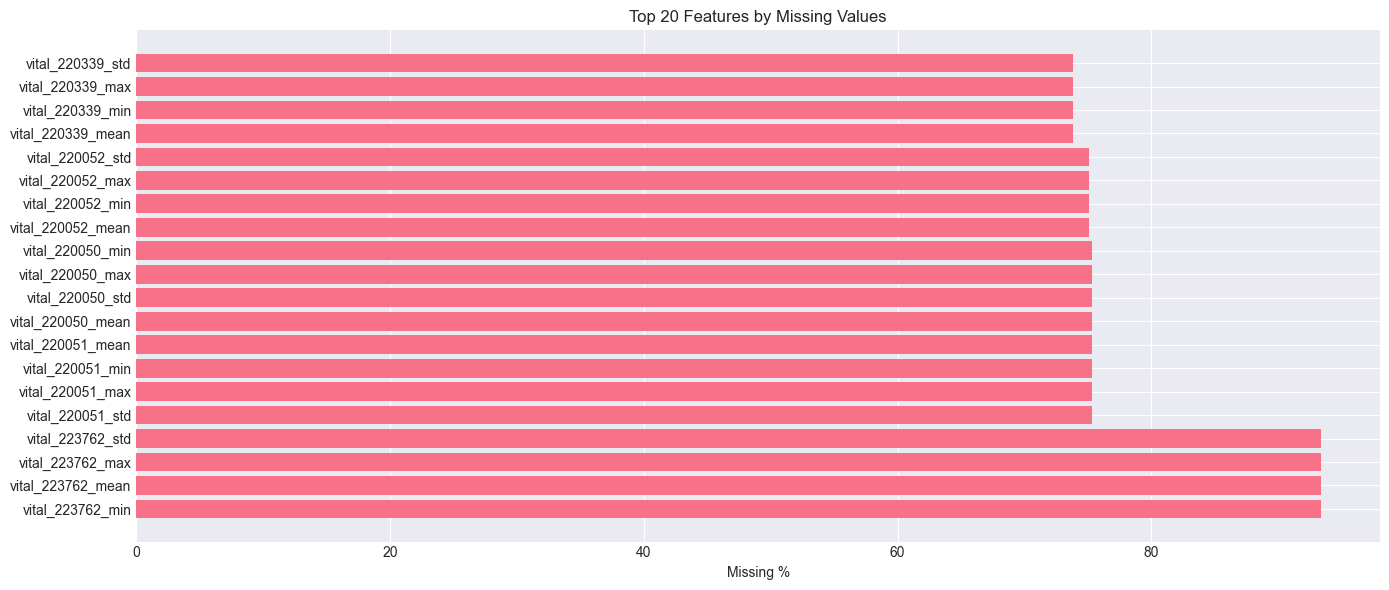


✅ Saved plot: results/agent3_missing_values.png


In [7]:
print("🔍 Analyzing missing values...")
print("=" * 60)

# Calculate missing percentage for each feature
missing_pct = (X.isnull().sum() / len(X) * 100).sort_values(ascending=False)

print(f"Features with missing values:")
print(missing_pct[missing_pct > 0].head(30))

print(f"\n📊 Missing value summary:")
print(f"   Total features: {X.shape[1]}")
print(f"   Features with >80% missing: {(missing_pct > 80).sum()}")
print(f"   Features with >50% missing: {(missing_pct > 50).sum()}")
print(f"   Features with >20% missing: {(missing_pct > 20).sum()}")
print(f"   Features with any missing: {(missing_pct > 0).sum()}")

# Visualize missing values
plt.figure(figsize=(14, 6))
top_missing = missing_pct[missing_pct > 0].head(20)
if len(top_missing) > 0:
    plt.barh(range(len(top_missing)), top_missing.values)
    plt.yticks(range(len(top_missing)), top_missing.index)
    plt.xlabel('Missing %')
    plt.title('Top 20 Features by Missing Values')
    plt.tight_layout()
    plt.savefig('../../results/agent3_missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Saved plot: results/agent3_missing_values.png")
else:
    print(f"\n✅ No significant missing values!")

In [8]:
print("🔧 Handling missing values...")
print("=" * 60)

# Drop features with >80% missing, impute rest
drop_threshold = 80.0

# Find features to drop
features_to_drop = missing_pct[missing_pct > drop_threshold].index.tolist()

print(f"Dropping {len(features_to_drop)} features with >{drop_threshold}% missing:")
for feat in features_to_drop:
    print(f"  - {feat}: {missing_pct[feat]:.1f}% missing")

# Drop features
X_reduced = X.drop(columns=features_to_drop)

print(f"\n✅ Features dropped!")
print(f"   Original features: {X.shape[1]}")
print(f"   Remaining features: {X_reduced.shape[1]}")
print(f"   Features removed: {X.shape[1] - X_reduced.shape[1]}")

# Impute remaining missing values with median
print(f"\n🔧 Imputing remaining missing values with median...")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_reduced),
    columns=X_reduced.columns,
    index=X_reduced.index
)

remaining_missing = X_imputed.isnull().sum().sum()
print(f"✅ Imputation complete!")
print(f"   Missing values remaining: {remaining_missing}")

if remaining_missing == 0:
    print(f"   ✅ No missing values! Ready for training.")

🔧 Handling missing values...
Dropping 4 features with >80.0% missing:
  - vital_223762_min: 93.4% missing
  - vital_223762_mean: 93.4% missing
  - vital_223762_max: 93.4% missing
  - vital_223762_std: 93.4% missing

✅ Features dropped!
   Original features: 66
   Remaining features: 62
   Features removed: 4

🔧 Imputing remaining missing values with median...
✅ Imputation complete!
   Missing values remaining: 0
   ✅ No missing values! Ready for training.


In [9]:
print("📏 Normalizing features (StandardScaler)...")
print("=" * 60)

# Create scaler
scaler = StandardScaler()

# Fit and transform
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

print(f"✅ Normalization complete!")
print(f"   Shape: {X_scaled.shape}")

# Verify normalization
print(f"\n📊 Normalization check:")
print(f"   Mean (should be ~0): {X_scaled.mean().mean():.6f}")
print(f"   Std (should be ~1):  {X_scaled.std().mean():.6f}")

print(f"\nSample feature statistics (first 5 features):")
print(X_scaled.iloc[:, :5].describe())

📏 Normalizing features (StandardScaler)...
✅ Normalization complete!
   Shape: (21816, 62)

📊 Normalization check:
   Mean (should be ~0): 0.000000
   Std (should be ~1):  1.000023

Sample feature statistics (first 5 features):
       vital_220045_mean  vital_220045_min  vital_220045_max  \
count       2.181600e+04      2.181600e+04      2.181600e+04   
mean        3.908376e-18      2.514388e-16     -1.954188e-18   
std         1.000023e+00      1.000023e+00      1.000023e+00   
min        -4.952479e-01     -1.189638e+01     -7.773074e-03   
25%        -9.737239e-03      5.091959e-02     -6.798206e-03   
50%        -9.737239e-03      5.091959e-02     -6.798206e-03   
75%        -9.737239e-03      5.091959e-02     -6.798206e-03   
max         1.470338e+02      5.747646e+00      1.476989e+02   

       vital_220045_std  vital_220045_count  
count      2.181600e+04        2.181600e+04  
mean       3.256980e-18       -2.019328e-17  
std        1.000023e+00        1.000023e+00  
min       -

In [10]:
print("🤖 Training XGBoost models (9 diseases)...")
print("=" * 60)

# Store models and results
models = {}
train_predictions = {}
train_metrics = {}

# Training parameters (same as Agent 1)
xgb_params = {
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1
}

print(f"XGBoost parameters:")
for param, value in xgb_params.items():
    print(f"  {param}: {value}")

print(f"\n{'='*60}")
print(f"Training {len(disease_cols)} models...")
print(f"{'='*60}\n")

# Train one model per disease
for disease in tqdm(disease_cols, desc="Training models"):
    # Get labels for this disease
    y_disease = y[disease].values
    
    # Train model
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_scaled, y_disease, verbose=False)
    
    # Make predictions
    y_pred_proba = model.predict_proba(X_scaled)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_disease, y_pred)
    f1 = f1_score(y_disease, y_pred)
    auc = roc_auc_score(y_disease, y_pred_proba)
    
    # Store results
    models[disease] = model
    train_predictions[disease] = y_pred_proba
    train_metrics[disease] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'auc_roc': auc,
        'positive_samples': int(y_disease.sum()),
        'prevalence': float(y_disease.mean())
    }
    
    print(f"{disease:30s}: Acc={accuracy:.3f}, F1={f1:.3f}, AUC={auc:.3f}")

print(f"\n✅ All models trained!")

🤖 Training XGBoost models (9 diseases)...
XGBoost parameters:
  max_depth: 6
  learning_rate: 0.1
  n_estimators: 100
  objective: binary:logistic
  eval_metric: auc
  random_state: 42
  n_jobs: -1

Training 9 models...



Training models:  11%|███████▍                                                           | 1/9 [00:02<00:21,  2.63s/it]

SEPSIS                        : Acc=0.889, F1=0.611, AUC=0.898


Training models:  22%|██████████████▉                                                    | 2/9 [00:03<00:10,  1.48s/it]

PNEUMONIA                     : Acc=0.868, F1=0.573, AUC=0.882


...

CORONARY_ARTERY_DISEASE       : Acc=0.736, F1=0.512, AUC=0.794


Training models:  89%|███████████████████████████████████████████████████████████▌       | 8/9 [00:07<00:00,  1.28it/s]

ANEMIA                        : Acc=0.801, F1=0.635, AUC=0.830


Training models: 100%|███████████████████████████████████████████████████████████████████| 9/9 [00:08<00:00,  1.06it/s]

PANCREATITIS                  : Acc=0.889, F1=0.389, AUC=0.859

✅ All models trained!


In [11]:
print("📊 Agent 3 (Vitals) Training Results")
print("=" * 80)

# Create metrics dataframe
train_metrics_df = pd.DataFrame(train_metrics).T
train_metrics_df = train_metrics_df.round(3)

print(train_metrics_df.to_string())

print(f"\n{'='*80}")
print(f"📈 Summary Statistics:")
print(f"   Average Accuracy: {train_metrics_df['accuracy'].mean():.3f} ± {train_metrics_df['accuracy'].std():.3f}")
print(f"   Average F1 Score: {train_metrics_df['f1_score'].mean():.3f} ± {train_metrics_df['f1_score'].std():.3f}")
print(f"   Average AUC-ROC:  {train_metrics_df['auc_roc'].mean():.3f} ± {train_metrics_df['auc_roc'].std():.3f}")

# Save metrics
train_metrics_df.to_csv('../../results/agent3_train_metrics.csv')
print(f"\n✅ Saved metrics: results/agent3_train_metrics.csv")

📊 Agent 3 (Vitals) Training Results
                         accuracy  f1_score  auc_roc  positive_samples  prevalence
SEPSIS                      0.889     0.611    0.898            4105.0       0.188
PNEUMONIA                   0.868     0.573    0.882            4555.0       0.209
RESPIRATORY_FAILURE         0.821     0.722    0.887            7913.0       0.363
ACUTE_KIDNEY_INJURY         0.836     0.761    0.896            8044.0       0.369
HEART_FAILURE               0.828     0.701    0.900            7069.0       0.324
ATRIAL_FIBRILLATION         0.795     0.660    0.857            7434.0       0.341
CORONARY_ARTERY_DISEASE     0.736     0.512    0.794            8354.0       0.383
ANEMIA                      0.801     0.635    0.830            7391.0       0.339
PANCREATITIS                0.889     0.389    0.859            3181.0       0.146

📈 Summary Statistics:
   Average Accuracy: 0.829 ± 0.049
   Average F1 Score: 0.618 ± 0.115
   Average AUC-ROC:  0.867 ± 0.036

✅ Sav

In [13]:
print("⚔️  AGENT COMPARISON (Training Performance)")
print("=" * 80)

# Load Agent 1 and Agent 2 training metrics
agent1_train = pd.read_csv('../../results/agent1_train_metrics.csv', index_col=0)
agent2_train_path = '../../results/agent2_train_metrics.csv'

print("Training AUC Comparison:")
print(f"\nAgent 1 (Labs)  - Training: {agent1_train['auc_roc'].mean():.3f}")
print(f"Agent 3 (Vitals) - Training: {train_metrics_df['auc_roc'].mean():.3f}")

# Create comparison for overlapping metrics
comparison = pd.DataFrame({
    'Agent1_Labs': agent1_train['auc_roc'],
    'Agent3_Vitals': train_metrics_df['auc_roc']
})

print(f"\n{'='*80}")
print("Per-Disease Comparison (Training AUC):")
print(comparison.round(3).to_string())

print(f"\n💡 NOTE: Agent 2 (Notes) training metrics not saved during Colab training")
print(f"   We have Agent 2 validation: 0.762 AUC")

⚔️  AGENT COMPARISON (Training Performance)
Training AUC Comparison:

Agent 1 (Labs)  - Training: 0.951
Agent 3 (Vitals) - Training: 0.867

Per-Disease Comparison (Training AUC):
                         Agent1_Labs  Agent3_Vitals
SEPSIS                         0.972          0.898
PNEUMONIA                      0.954          0.882
RESPIRATORY_FAILURE            0.942          0.887
ACUTE_KIDNEY_INJURY            0.988          0.896
HEART_FAILURE                  0.936          0.900
ATRIAL_FIBRILLATION            0.929          0.857
CORONARY_ARTERY_DISEASE        0.948          0.794
ANEMIA                         0.922          0.830
PANCREATITIS                   0.968          0.859

💡 NOTE: Agent 2 (Notes) training metrics not saved during Colab training
   We have Agent 2 validation: 0.762 AUC


In [14]:
print("🔍 Analyzing feature importance for Agent 3...")
print("=" * 60)

# Extract feature importance for each disease
feature_importance = {}

for disease in disease_cols:
    # Get feature importance from model
    importance = models[disease].feature_importances_
    
    # Create dataframe
    imp_df = pd.DataFrame({
        'feature': X_scaled.columns,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    feature_importance[disease] = imp_df
    
    print(f"\n{disease}:")
    print(f"  Top 10 important vital features:")
    for idx, row in imp_df.head(10).iterrows():
        print(f"    {row['feature']:30s}: {row['importance']:.4f}")

print(f"\n✅ Feature importance analyzed for all diseases")

🔍 Analyzing feature importance for Agent 3...

SEPSIS:
  Top 10 important vital features:
    NUM_DISEASES                  : 0.2640
    vital_223761_max              : 0.0226
    vital_220045_mean             : 0.0220
    vital_220339_count            : 0.0204
    vital_220179_min              : 0.0195
    vital_223835_max              : 0.0193
    vital_220179_mean             : 0.0168
    vital_220052_count            : 0.0162
    vital_223835_count            : 0.0159
    vital_220050_min              : 0.0142

PNEUMONIA:
  Top 10 important vital features:
    NUM_DISEASES                  : 0.2671
    vital_220052_mean             : 0.0247
    vital_223835_count            : 0.0225
    vital_223761_max              : 0.0216
    vital_220052_count            : 0.0209
    vital_220052_max              : 0.0180
    vital_220052_std              : 0.0179
    vital_220210_mean             : 0.0166
    vital_220277_mean             : 0.0163
    vital_223762_count            : 0.0161

RE

📊 Creating feature importance visualizations...


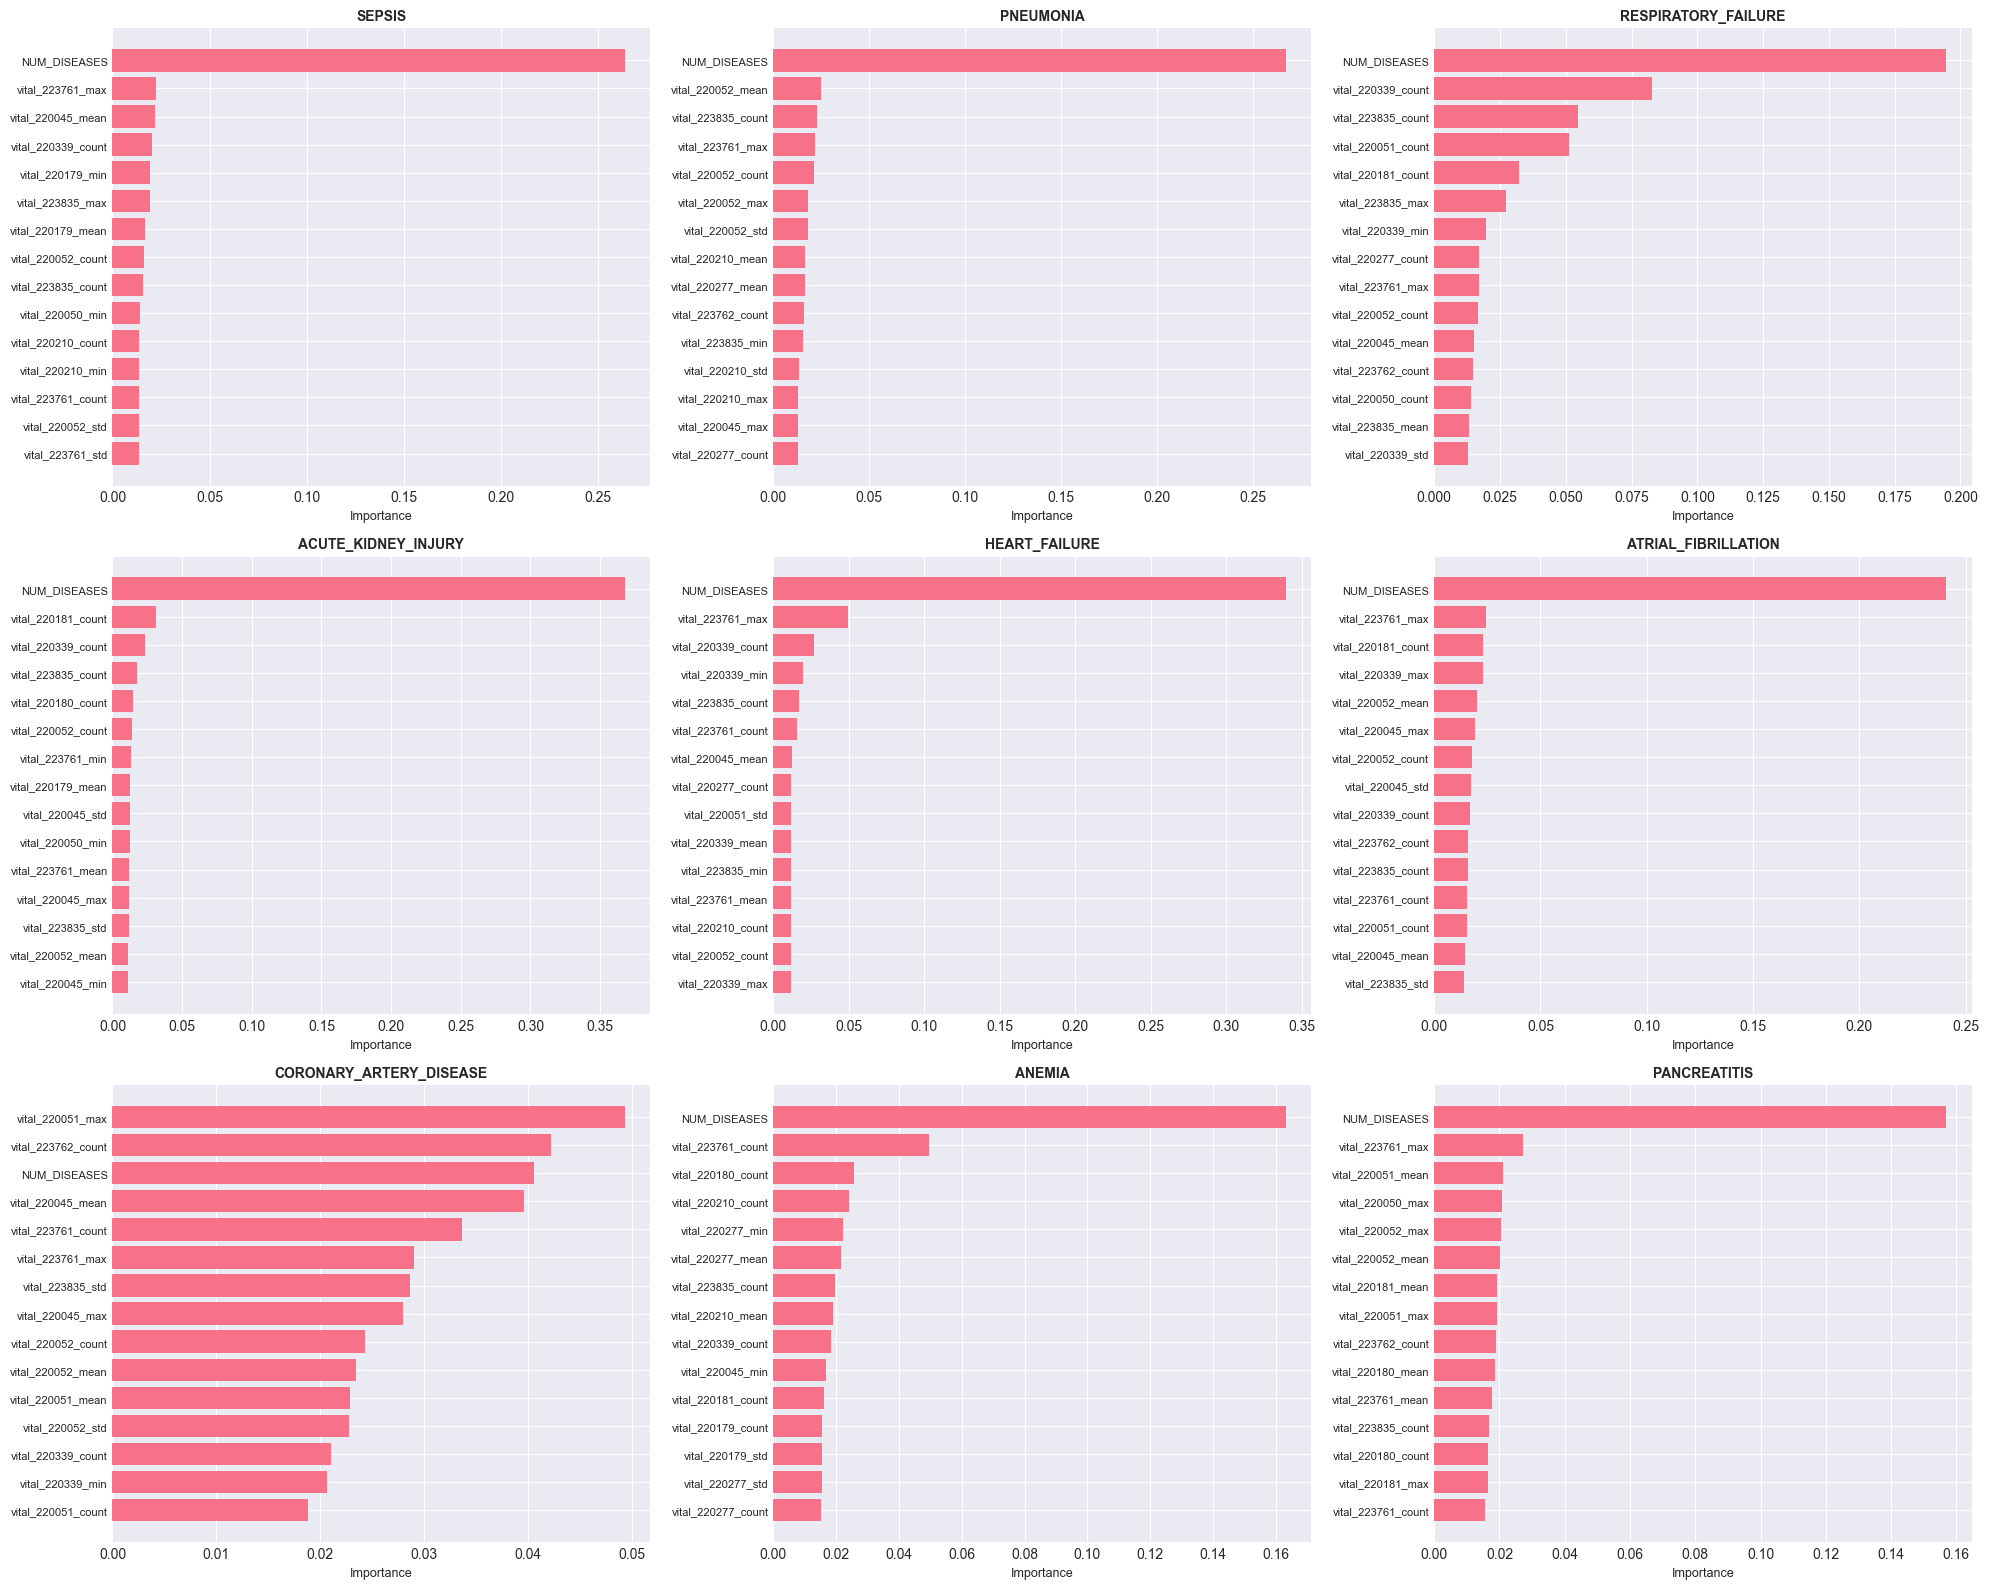

✅ Saved plot: results/agent3_feature_importance.png


In [15]:
print("📊 Creating feature importance visualizations...")
print("=" * 60)

# Create subplot for each disease
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for idx, disease in enumerate(disease_cols):
    ax = axes[idx]
    
    # Get top 15 features
    top_features = feature_importance[disease].head(15)
    
    # Plot
    ax.barh(range(len(top_features)), top_features['importance'].values)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'].values, fontsize=8)
    ax.set_xlabel('Importance', fontsize=9)
    ax.set_title(f'{disease}', fontsize=10, fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../results/agent3_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved plot: results/agent3_feature_importance.png")

In [16]:
print("💾 Saving models and preprocessing objects...")
print("=" * 60)

# Save models
for disease, model in models.items():
    filename = f'../../models/agent3_{disease.lower()}.joblib'
    joblib.dump(model, filename)
    print(f"  ✅ Saved: {filename}")

# Save preprocessing objects
joblib.dump(imputer, '../../models/agent3_imputer.joblib')
joblib.dump(scaler, '../../models/agent3_scaler.joblib')

# Save preprocessing info
preprocessing_info = {
    'features_used': X_scaled.columns.tolist(),
    'features_dropped': features_to_drop,
    'n_features': X_scaled.shape[1],
    'imputation_strategy': 'median',
    'scaling_method': 'StandardScaler',
    'patients_with_vitals': len(X_scaled)
}

import json
with open('../../models/agent3_preprocessing_info.json', 'w') as f:
    json.dump(preprocessing_info, f, indent=2)

print(f"\n✅ Saved preprocessing objects:")
print(f"  - Imputer: models/agent3_imputer.joblib")
print(f"  - Scaler: models/agent3_scaler.joblib")
print(f"  - Info: models/agent3_preprocessing_info.json")

print(f"\n🎉 All models and objects saved!")

💾 Saving models and preprocessing objects...
  ✅ Saved: ../models/agent3_sepsis.joblib
  ✅ Saved: ../models/agent3_pneumonia.joblib
  ✅ Saved: ../models/agent3_respiratory_failure.joblib
  ✅ Saved: ../models/agent3_acute_kidney_injury.joblib
  ✅ Saved: ../models/agent3_heart_failure.joblib
  ✅ Saved: ../models/agent3_atrial_fibrillation.joblib
  ✅ Saved: ../models/agent3_coronary_artery_disease.joblib
  ✅ Saved: ../models/agent3_anemia.joblib
  ✅ Saved: ../models/agent3_pancreatitis.joblib

✅ Saved preprocessing objects:
  - Imputer: models/agent3_imputer.joblib
  - Scaler: models/agent3_scaler.joblib
  - Info: models/agent3_preprocessing_info.json

🎉 All models and objects saved!
